## Importing Libraries and reading data

In [1]:
# Reproducibility
import numpy as np
import torch
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn
import torch.optim as optim

In [2]:
# Load dataset
df = pd.read_csv("bank-additional-full.csv", sep=";")

print("Shape:", df.shape)
df.head().T

Shape: (41188, 21)


,0,1,2,3,4
age,56,57,37,40,56
job,housemaid,services,services,admin.,services
marital,married,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school
default,no,unknown,no,no,no
housing,no,no,yes,no,no
loan,no,no,no,no,yes
contact,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may
day_of_week,mon,mon,mon,mon,mon


## Processing data

In [3]:
# Encode categorical columns
df = df.apply(LabelEncoder().fit_transform)

# Split features / target
X = df.drop("y", axis=1).values
y = df["y"].values

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

print("Training samples:", X_train.shape)

Training samples: torch.Size([32950, 20])


## Models Training

In [4]:
def train_model(model, epochs=30, lr=0.001, use_pos_weight=True):

    if use_pos_weight:
        pos_weight = torch.tensor([7.0])
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

        # ----- TRAIN -----
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        acc = (preds == y_train).float().mean()

        train_losses.append(loss.item())
        train_accs.append(acc.item())

        # ----- VALIDATION -----
        model.eval()
        with torch.no_grad():

            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)

            val_preds = (torch.sigmoid(val_outputs) > 0.5).float()
            val_acc = (val_preds == y_test).float().mean()

        val_losses.append(val_loss.item())
        val_accs.append(val_acc.item())

        if epoch % max(1, epochs // 5) == 0:
            print(f"Epoch {epoch} | Train Loss {loss:.4f} | Val Loss {val_loss:.4f} | Train Acc {acc:.3f} | Val Acc {val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs


In [5]:
# Sanity check: train on single sample
sample_X = X_train[:1]
sample_y = y_train[:1]

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for i in range(200):
    output = model(sample_X)
    loss = criterion(output, sample_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Final loss on single sample:", loss.item())

Final loss on single sample: 0.0030884742736816406


as we see final loss aproaches zero as we have only one sample

### Simple model --> underfit

In [6]:
# Simple small network (likely underfitting)

model1 = nn.Sequential(
    nn.Linear(X_train.shape[1], 4),
    nn.ReLU(),
    nn.Linear(4,1)
)

print(model1)


Sequential(
  (0): Linear(in_features=20, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)


### Complex model --> over fit 

This model has many parameters and is likely to overfit the training data.

In [7]:
# Large network to encourage overfitting

model2 = nn.Sequential(
    nn.Linear(X_train.shape[1],128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)

print(model2)


Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


### Regularization + Dropout

In [8]:
# Regularized network

model3 = nn.Sequential(
    nn.Linear(X_train.shape[1],64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32,1)
)

print(model3)


Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
print("------------MODEL 1-------------")
train1, val1, acc1_train, acc1_val = train_model(model1, epochs=30)

print("------------MODEL 2-------------")

train2, val2, acc2_train, acc2_val = train_model(model2, epochs=300, lr=0.01, use_pos_weight=False)

print("------------MODEL 3-------------")

train3, val3, acc3_train, acc3_val = train_model(model3, epochs=150)


Epoch 0 | Train Loss 1.2116 | Val Loss 1.2134 | Train Acc 0.888 | Val Acc 0.887
Epoch 6 | Train Loss 1.1908 | Val Loss 1.1935 | Train Acc 0.888 | Val Acc 0.887
Epoch 12 | Train Loss 1.1729 | Val Loss 1.1764 | Train Acc 0.888 | Val Acc 0.887
Epoch 18 | Train Loss 1.1575 | Val Loss 1.1618 | Train Acc 0.888 | Val Acc 0.887
Epoch 24 | Train Loss 1.1444 | Val Loss 1.1494 | Train Acc 0.888 | Val Acc 0.887
Epoch 0 | Train Loss 0.6627 | Val Loss 0.5876 | Train Acc 0.886 | Val Acc 0.887
Epoch 60 | Train Loss 0.1830 | Val Loss 0.1877 | Train Acc 0.914 | Val Acc 0.913
Epoch 120 | Train Loss 0.1541 | Val Loss 0.1929 | Train Acc 0.928 | Val Acc 0.909
Epoch 180 | Train Loss 0.1316 | Val Loss 0.2285 | Train Acc 0.941 | Val Acc 0.900
Epoch 240 | Train Loss 0.1123 | Val Loss 0.2748 | Train Acc 0.953 | Val Acc 0.902
Epoch 0 | Train Loss 1.1845 | Val Loss 1.1754 | Train Acc 0.548 | Val Acc 0.500
Epoch 30 | Train Loss 0.8914 | Val Loss 0.8654 | Train Acc 0.773 | Val Acc 0.781
Epoch 60 | Train Loss 0.6590 

## Evaluation

In [10]:
from sklearn.metrics import classification_report

def evaluate(model):
    
    model.eval()
    
    with torch.no_grad():
        outputs = model(X_test)
        preds = (torch.sigmoid(outputs) > 0.5).int()

    print(classification_report(y_test, preds))

print("Model 1")
evaluate(model1)

print("Model 2")
evaluate(model2)

print("Model 3")
evaluate(model3)

Model 1
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94      7303
         1.0       0.00      0.00      0.00       935

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238

Model 2
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94      7303
         1.0       0.56      0.53      0.54       935

    accuracy                           0.90      8238
   macro avg       0.75      0.74      0.74      8238
weighted avg       0.90      0.90      0.90      8238

Model 3
              precision    recall  f1-score   support

         0.0       0.99      0.83      0.90      7303
         1.0       0.41      0.91      0.56       935

    accuracy                           0.84      8238
   macro avg       0.70      0.87      0.73      8238
weighted avg       0.92      0.84      0.86      8

d:\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


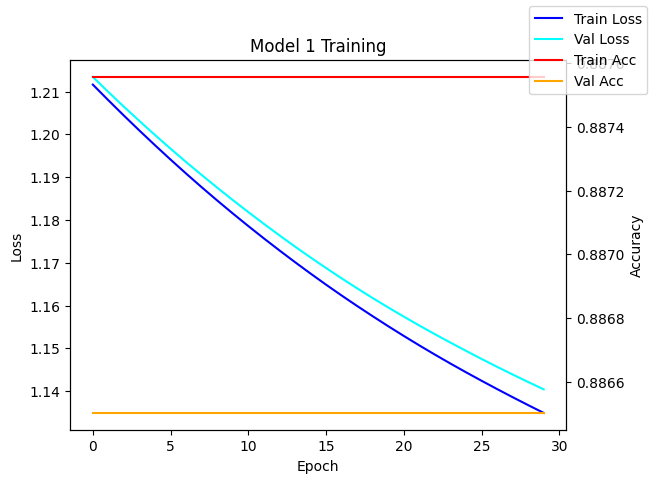

In [11]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Loss
ax1.plot(train1, label="Train Loss", color="blue")
ax1.plot(val1, label="Val Loss", color="cyan")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")

# Accuracy
ax2 = ax1.twinx()
ax2.plot(acc1_train, label="Train Acc", color="red")
ax2.plot(acc1_val, label="Val Acc", color="orange")
ax2.set_ylabel("Accuracy")

fig.legend(loc="upper right")
plt.title("Model 1 Training")
plt.show()

for the first model its obvious that it is too simple to fit the data and can't generalize at all it has high loss in both training and validation and low accuracy in both too

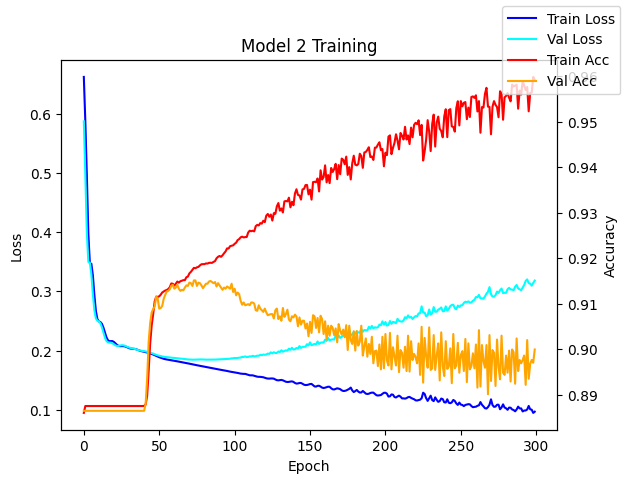

In [12]:
fig, ax1 = plt.subplots()

ax1.plot(train2, label="Train Loss", color="blue")
ax1.plot(val2, label="Val Loss", color="cyan")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")

ax2 = ax1.twinx()
ax2.plot(acc2_train, label="Train Acc", color="red")
ax2.plot(acc2_val, label="Val Acc", color="orange")
ax2.set_ylabel("Accuracy")

fig.legend(loc="upper right")
plt.title("Model 2 Training")
plt.show()

for the second model as we can see here, the training process was going ver well accuracies increasing and loss dropping until some point were the model started over fitting the problem and validation loss started increasing again while training loss kept decreasing.

that shows pure over fitting as the model failed to generalize at all on the test data

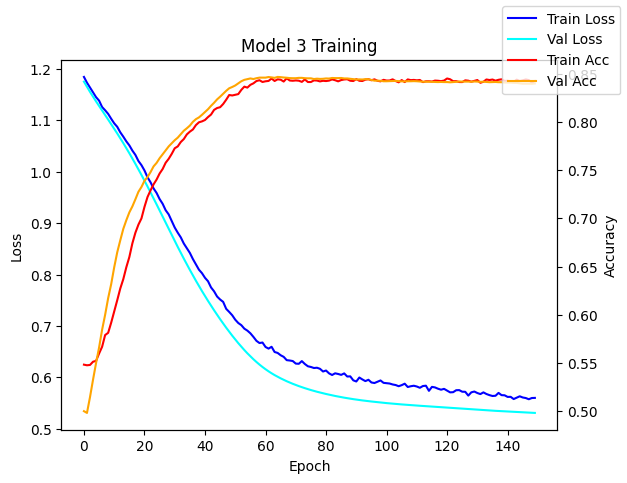

In [13]:
fig, ax1 = plt.subplots()

ax1.plot(train3, label="Train Loss", color="blue")
ax1.plot(val3, label="Val Loss", color="cyan")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")

ax2 = ax1.twinx()
ax2.plot(acc3_train, label="Train Acc", color="red")
ax2.plot(acc3_val, label="Val Acc", color="orange")
ax2.set_ylabel("Accuracy")

fig.legend(loc="upper right")
plt.title("Model 3 Training")
plt.show()

for the final model:

every thing is looking fine as we made a good mix of complexity and regularization.

validation and training loss kept dropping consistently together, same for accuracies kept rising together

that's an example of good model fit that generalizes to the data and not just memorize a pattern and stick to it



Conclusion:

 Model 1 was too simple and underfit, Model 2 was intentionally complex and showed clear overfitting, and Model 3 used dropout/regularization to achieve the best balance between learning and generalization. This comparison confirms that model capacity alone is not enough, controlled complexity with proper regularization gives more reliable performance on unseen data.